In [1]:
import pandas as pd

df = pd.read_csv("../data/postings.csv")

df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-sy...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 perfo...,"Business Analysis, Technical Writing, Software..."
3,Senior VAT and Indirect Tax Analyst,Epic,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-vat-...,2023-12-20,Bloomington,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Accounting, Finance, VAT/GST tax regimes, US a..."
4,Senior HRIS Analyst (Timekeeping and Payroll),Nordson Corporation,Greater Bloomington Area,https://www.linkedin.com/jobs/view/senior-hris...,2023-12-20,Bloomington,United States,Mid senior,Remote,Collaboration drives Nordson’s success as a ma...,"Workday HCM, UKG Dimensions, Ceridian Dayforce..."


In [2]:
df.shape

(12894, 11)

In [3]:
df.columns.tolist()

['job_title',
 'company',
 'job_location',
 'job_link',
 'first_seen',
 'search_city',
 'search_country',
 'job level',
 'job_type',
 'job_summary',
 'job_skills']

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

job_title           0
company             0
job_location        0
job_link            0
first_seen          0
search_city         0
search_country      0
job level           0
job_type            0
job_summary        43
job_skills        189
dtype: int64

In [ ]:
df_clean=df.copy()

In [7]:
df_clean.columns = df_clean.columns.str.strip().str.lower().str.replace(" ", "_")

In [8]:
df_clean.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job_level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [9]:
df_clean["first_seen"] = pd.to_datetime(df_clean["first_seen"])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   job_title       12894 non-null  object        
 1   company         12894 non-null  object        
 2   job_location    12894 non-null  object        
 3   job_link        12894 non-null  object        
 4   first_seen      12894 non-null  datetime64[ns]
 5   search_city     12894 non-null  object        
 6   search_country  12894 non-null  object        
 7   job_level       12894 non-null  object        
 8   job_type        12894 non-null  object        
 9   job_summary     12851 non-null  object        
 10  job_skills      12705 non-null  object        
dtypes: datetime64[ns](1), object(10)
memory usage: 1.1+ MB


In [10]:
print("Before:", len(df_clean))

df_clean = df_clean.drop_duplicates()

print("After:", len(df_clean))

Before: 12894
After: 12894


In [11]:
df_clean["job_skills"] = df_clean["job_skills"].fillna("Not Specified")
df_clean["job_summary"] = df_clean["job_summary"].fillna("Not Available")

In [12]:
df_clean.isnull().sum()

job_title         0
company           0
job_location      0
job_link          0
first_seen        0
search_city       0
search_country    0
job_level         0
job_type          0
job_summary       0
job_skills        0
dtype: int64

In [13]:
df_clean.to_csv("../data/jobs_cleaned.csv", index=False)

In [14]:
df_clean["job_skills"].sample(5)

11158    Underwriting, Microsoft Office, Communication,...
4192     Slate, Peoplesoft, OnBase, OCR software, CRM, ...
2719     Data Analysis, Market Research, Healthcare, SQ...
9535                                         Not Specified
443      Business Analysis, Software Development, Tacti...
Name: job_skills, dtype: object

In [16]:
all_skills = []

for skills in df_clean["job_skills"]:
    for skill in str(skills).split(","):
        all_skills.append(skill.strip())

In [17]:
from collections import Counter

skill_counts = Counter(all_skills)

skill_counts.most_common(20)

[('SQL', 4286),
 ('Data Analysis', 2828),
 ('Communication', 2466),
 ('Tableau', 2153),
 ('Excel', 2150),
 ('Python', 2132),
 ('Data analysis', 1819),
 ('Power BI', 1741),
 ('Project Management', 1588),
 ('Reporting', 1389),
 ('Data Visualization', 1389),
 ('Business Analysis', 1217),
 ('R', 1211),
 ('Problem Solving', 981),
 ('Teamwork', 976),
 ('Agile', 944),
 ('Project management', 930),
 ('Microsoft Excel', 923),
 ('Data visualization', 907),
 ('Microsoft Office Suite', 884)]

In [18]:
skills_df = pd.DataFrame(
    skill_counts.items(),
    columns=["skill", "count"]
)

skills_df = skills_df.sort_values(
    by="count",
    ascending=False
)

skills_df.head(20)

,skill,count
98,SQL,4286
230,Data Analysis,2828
106,Communication,2466
502,Tableau,2153
16,Excel,2150
394,Python,2132
1,Data analysis,1819
503,Power BI,1741
105,Project Management,1588
75,Reporting,1389


In [19]:
skills_df = skills_df[
    skills_df["skill"] != "Not Specified"
]

skills_df.head(20)

,skill,count
98,SQL,4286
230,Data Analysis,2828
106,Communication,2466
502,Tableau,2153
16,Excel,2150
394,Python,2132
1,Data analysis,1819
503,Power BI,1741
105,Project Management,1588
75,Reporting,1389


In [20]:
skills_df.to_csv(
    "../data/skills_analysis.csv",
    index=False
)

In [21]:
skills_df.head(20)

,skill,count
98,SQL,4286
230,Data Analysis,2828
106,Communication,2466
502,Tableau,2153
16,Excel,2150
394,Python,2132
1,Data analysis,1819
503,Power BI,1741
105,Project Management,1588
75,Reporting,1389


In [22]:
def normalize_skill(skill):
    skill = skill.strip()

    mapping = {
        "Data analysis": "Data Analysis",
        "Project management": "Project Management",
        "Data visualization": "Data Visualization",
        "Microsoft Excel": "Excel"
    }

    return mapping.get(skill, skill)

In [23]:
all_skills_clean = []

for skills in df_clean["job_skills"]:
    for skill in str(skills).split(","):
        all_skills_clean.append(normalize_skill(skill))

In [24]:
from collections import Counter

skill_counts_clean = Counter(all_skills_clean)

skills_df_clean = pd.DataFrame(
    skill_counts_clean.items(),
    columns=["skill", "count"]
)

skills_df_clean = skills_df_clean.sort_values(
    by="count",
    ascending=False
)

skills_df_clean = skills_df_clean[
    skills_df_clean["skill"] != "Not Specified"
]

skills_df_clean.head(20)

,skill,count
1,Data Analysis,4647
98,SQL,4286
16,Excel,3073
8,Project Management,2518
104,Communication,2466
12,Data Visualization,2296
498,Tableau,2153
390,Python,2132
499,Power BI,1741
75,Reporting,1389


In [25]:
skills_df_clean.to_csv(
    "../data/skills_analysis_clean.csv",
    index=False
)

In [26]:
skills_df_clean.head(15)

,skill,count
1,Data Analysis,4647
98,SQL,4286
16,Excel,3073
8,Project Management,2518
104,Communication,2466
12,Data Visualization,2296
498,Tableau,2153
390,Python,2132
499,Power BI,1741
75,Reporting,1389


C:\Users\Akshatha jogi\AppData\Local\Temp\ipykernel_68436\1142278522.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


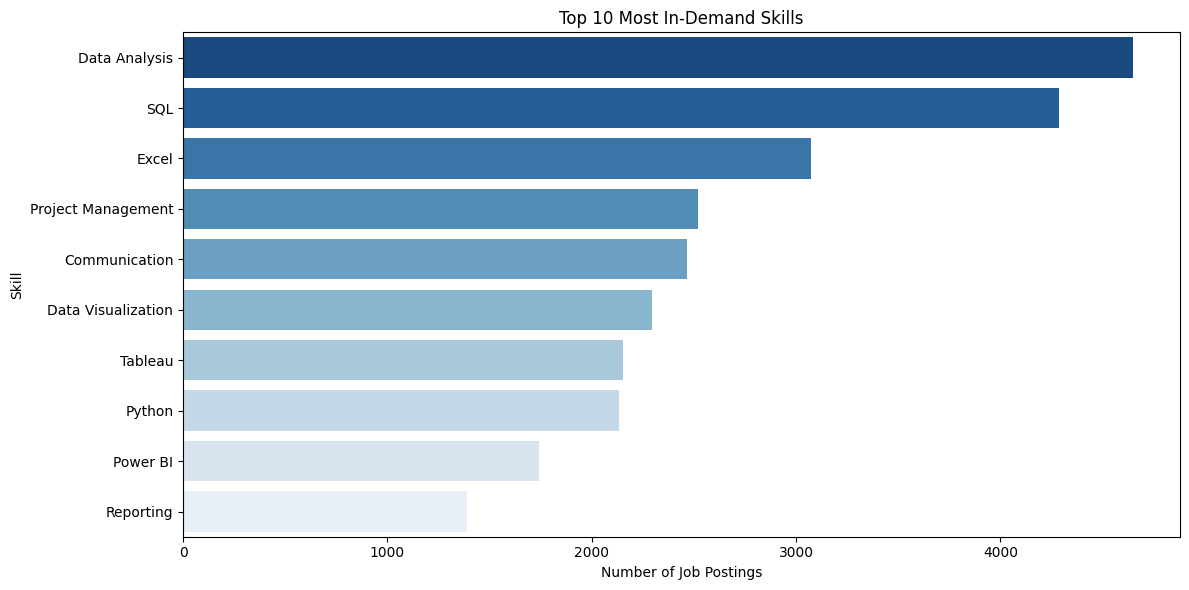

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

top10 = skills_df_clean.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="count",
    y="skill",
    palette="Blues_r"
)

plt.title("Top 10 Most In-Demand Skills")
plt.xlabel("Number of Job Postings")
plt.ylabel("Skill")

plt.tight_layout()
plt.show()

C:\Users\Akshatha jogi\AppData\Local\Temp\ipykernel_68436\2909948415.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


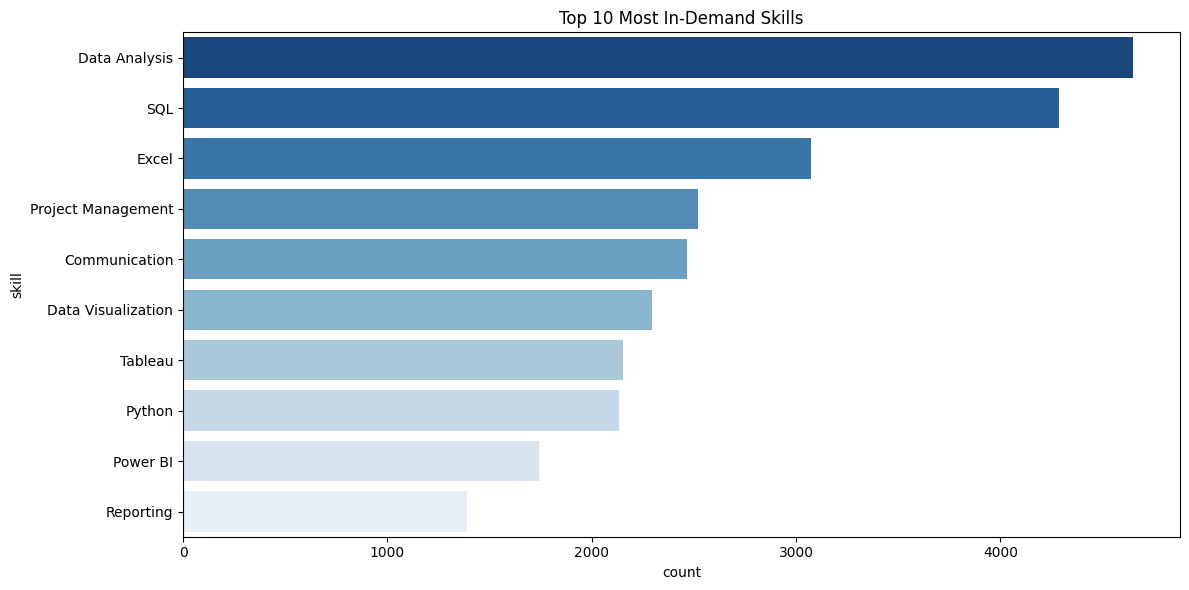

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="count",
    y="skill",
    palette="Blues_r"
)

plt.title("Top 10 Most In-Demand Skills")

plt.tight_layout()

plt.savefig(
    "../screenshots/top10_skills.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [29]:
job_titles = (
    df_clean["job_title"]
    .value_counts()
    .reset_index()
)

job_titles.columns = ["job_title", "count"]

job_titles.head(20)

,job_title,count
0,Business Analyst,438
1,Data Analyst,332
2,Senior Financial Analyst,278
3,Senior Data Analyst,235
4,Business Systems Analyst,199
5,Business Intelligence Analyst,142
6,Senior VAT and Indirect Tax Analyst,97
7,Business System Analyst,89
8,35F Intelligence Analyst,83
9,Lead Analyst Identity Governance and Administr...,73


In [30]:
job_titles.to_csv(
    "../data/job_title_analysis.csv",
    index=False
)

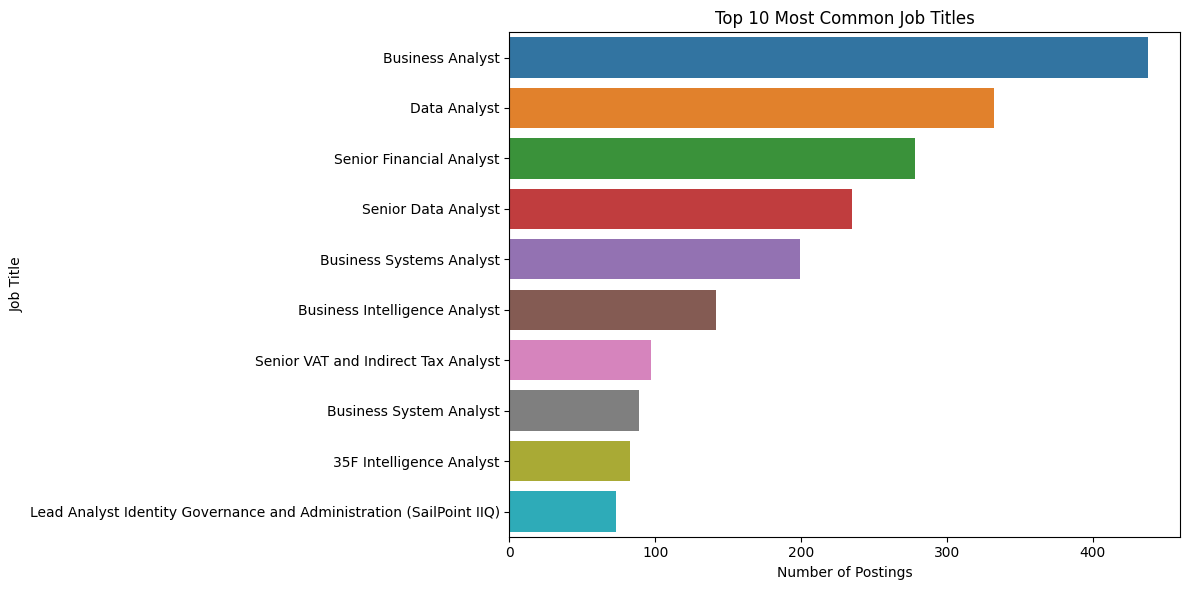

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

top_titles = job_titles.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_titles,
    x="count",
    y="job_title",
    hue="job_title",
    legend=False
)

plt.title("Top 10 Most Common Job Titles")
plt.xlabel("Number of Postings")
plt.ylabel("Job Title")

plt.tight_layout()
plt.show()

In [32]:
job_titles.head(20)

,job_title,count
0,Business Analyst,438
1,Data Analyst,332
2,Senior Financial Analyst,278
3,Senior Data Analyst,235
4,Business Systems Analyst,199
5,Business Intelligence Analyst,142
6,Senior VAT and Indirect Tax Analyst,97
7,Business System Analyst,89
8,35F Intelligence Analyst,83
9,Lead Analyst Identity Governance and Administr...,73


In [33]:
job_type_analysis = (
    df_clean["job_type"]
    .value_counts()
    .reset_index()
)

job_type_analysis.columns = ["job_type", "count"]

job_type_analysis

,job_type,count
0,Onsite,6670
1,Hybrid,4339
2,Remote,1885


In [34]:
job_type_analysis.to_csv(
    "../data/job_type_analysis.csv",
    index=False
)

In [35]:
job_level_analysis = (
    df_clean["job_level"]
    .value_counts()
    .reset_index()
)

job_level_analysis.columns = ["job_level", "count"]

job_level_analysis

,job_level,count
0,Mid senior,9691
1,Associate,3203


In [36]:
job_level_analysis.to_csv(
    "../data/job_level_analysis.csv",
    index=False
)

In [37]:
df_clean["job_title"].value_counts().head(20)

job_title
Business Analyst                                                       438
Data Analyst                                                           332
Senior Financial Analyst                                               278
Senior Data Analyst                                                    235
Business Systems Analyst                                               199
Business Intelligence Analyst                                          142
Senior VAT and Indirect Tax Analyst                                     97
Business System Analyst                                                 89
35F Intelligence Analyst                                                83
Lead Analyst Identity Governance and Administration (SailPoint IIQ)     73
Business Data Analyst                                                   73
Senior Associate, Senior Security Operations Analyst                    71
Senior Business Analyst                                                 69
Technical Busin

In [38]:
def categorize_role(title):
    title = str(title).lower()

    if "business intelligence analyst" in title:
        return "Business Intelligence Analyst"

    elif "business analyst" in title:
        return "Business Analyst"

    elif "data analyst" in title:
        return "Data Analyst"

    else:
        return "Other Analyst"


df_clean["role_category"] = df_clean["job_title"].apply(categorize_role)

In [39]:
df_clean["role_category"].value_counts()

role_category
Other Analyst                    7614
Data Analyst                     2729
Business Analyst                 2225
Business Intelligence Analyst     326
Name: count, dtype: int64

In [40]:
df_clean.to_csv(
    "../data/jobs_dashboard_ready.csv",
    index=False
)

In [41]:
role_skill_rows = []

for _, row in df_clean.iterrows():

    role = row["role_category"]

    skills = str(row["job_skills"]).split(",")

    for skill in skills:
        role_skill_rows.append(
            [role, skill.strip()]
        )

role_skill_df = pd.DataFrame(
    role_skill_rows,
    columns=["role", "skill"]
)

role_skill_df.head()

,role,skill
0,Data Analyst,Not Specified
1,Other Analyst,Data analysis
2,Other Analyst,Market research
3,Other Analyst,Survey development
4,Other Analyst,Analytical methods


In [42]:
role_skill_df.shape

(229030, 2)

In [43]:
role_skill_counts = (
    role_skill_df
    .groupby(["role", "skill"])
    .size()
    .reset_index(name="count")
)

role_skill_counts.head()

,role,skill,count
0,Business Analyst,* Business Analysis,1
1,Business Analyst,* Business Analytics,1
2,Business Analyst,* Business Intelligence,1
3,Business Analyst,* Business Process Documentation,1
4,Business Analyst,* Confluence,1


In [44]:
role_skill_counts.to_csv(
    "../data/role_skill_counts.csv",
    index=False
)

In [45]:
role_skill_counts.sort_values(
    "count",
    ascending=False
).head(20)

,role,skill,count
56534,Other Analyst,SQL,1908
23254,Data Analyst,SQL,1656
32618,Other Analyst,Communication,1433
39043,Other Analyst,Excel,1234
34869,Other Analyst,Data Analysis,1229
16497,Data Analyst,Data Analysis,1114
35581,Other Analyst,Data analysis,1031
24315,Data Analyst,Tableau,1025
22415,Data Analyst,Python,976
53647,Other Analyst,Python,957


In [46]:
role_skill_df["skill"] = role_skill_df["skill"].str.strip()

role_skill_df["skill"] = role_skill_df["skill"].replace({
    "Data analysis": "Data Analysis",
    "Project management": "Project Management",
    "Microsoft Excel": "Excel",
    "Data visualization": "Data Visualization"
})

In [47]:
role_skill_counts = (
    role_skill_df
    .groupby(["role", "skill"])
    .size()
    .reset_index(name="count")
)